In [217]:
import numpy as np
import matplotlib.pyplot as plt

# Task 1

In [218]:
def simulate_a_woman(X0,P): 
    states = np.array([0,1,2,3,4])
    States = []
    current_state =X0

    while current_state !=4:
        current_state = np.random.choice(states, p=P[current_state])
        States.append(current_state)
    return np.array(States)

In [219]:
# Task 1
P = np.array([
    [0.9915, 0.0050, 0.0025, 0.0000, 0.0010],
    [0.0000, 0.9860, 0.0050, 0.0040, 0.0050],
    [0.0000, 0.0000, 0.9920, 0.0030, 0.0050],
    [0.0000, 0.0000, 0.0000, 0.9910, 0.0090],
    [0.0000, 0.0000, 0.0000, 0.0000, 1.0000]
])

Lifetime = []
Women_with_local_cancer = 0
np.random.seed(42)
for i in range(1000):
    X = simulate_a_woman(0,P)
    Lifetime.append(len(X))
    if 1 in X:
        Women_with_local_cancer+=1
    elif 3 in X:
        Women_with_local_cancer+=1




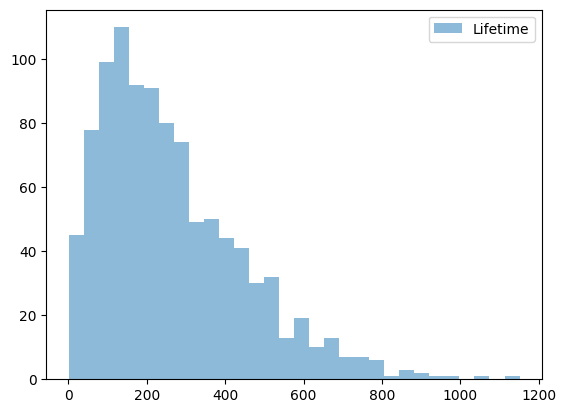

In [220]:
plt.hist(Lifetime, bins=30, alpha=0.5, label="Lifetime")

plt.legend()
plt.show()

In [221]:
Women_with_local_cancer/1000

0.712

# Task 2

In [222]:
P = np.array([
    [0.9915, 0.0050, 0.0025, 0.0000, 0.0010],
    [0.0000, 0.9860, 0.0050, 0.0040, 0.0050],
    [0.0000, 0.0000, 0.9920, 0.0030, 0.0050],
    [0.0000, 0.0000, 0.0000, 0.9910, 0.0090],
    [0.0000, 0.0000, 0.0000, 0.0000, 1.0000]
])
p0 = np.array([1000,0,0,0,0])
p=p0
for t in range(120):
    p = p@P
    if p[-1]>=999.5:
        break


In [223]:
# Theoretical distributtion at time 120
p

array([359.02626821, 158.95603979, 166.08689731,  67.74149395,
       248.18930075])

In [224]:
State_at_120 = []
np.random.seed(42)
for i in range(1000):
    X = simulate_a_woman(0,P)
    if len(X)>=120:
        State_at_120.append(X[119])
    else: 
        State_at_120.append(4)

In [225]:
# We do chi_square to test if distribution is the same
from scipy.stats import chisquare
observed_120 =  np.bincount(State_at_120)
chi2_stat, p_value = chisquare(
    f_obs=observed_120,
    f_exp=p
)

In [226]:
p_value

0.9055179937377961

In [227]:
pi = np.array([1,0,0,0])
Ps = np.array([
    [0.9915, 0.0050, 0.0025, 0.0000],
    [0.0000, 0.9860, 0.0050, 0.0040],
    [0.0000, 0.0000, 0.9920, 0.0030],
    [0.0000, 0.0000, 0.0000, 0.9910],
])
ps = np.array([0.0010,0.005,0.005,0.009])

Theoretical_number = []
T = []
for t in range(1,np.max(Lifetime)+1):
    T.append(t)
    prop = pi@np.linalg.matrix_power(Ps, t)@ps
    Theoretical_number.append(prop)
    


In [228]:
sum(Theoretical_number)

0.9975756805240262

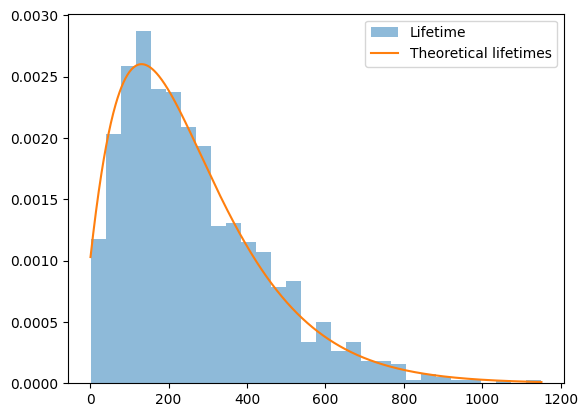

In [229]:
plt.hist(Lifetime, bins=30, alpha=0.5, label="Lifetime",density=True)
plt.plot(T,Theoretical_number,label = "Theoretical lifetimes")

plt.legend()
plt.show()

# Task 4

In [230]:
Women = []
np.random.seed(42)
while len(Women)!=1000:
    X = simulate_a_woman(0,P)
    if (1 in X[:12]) and (len(X)>12):
        Women.append(X) 

    elif (2 in X[:12]) and (len(X)>12):
        Women.append(X) 


In [231]:
Lifetimes_task4 =[]
for woman in Women:
    Lifetimes_task4.append(len(woman))

In [232]:
np.mean(Lifetimes_task4)

178.715

In [233]:
np.mean(Lifetime)

265.035

# Task 5

In [234]:
def simulate_a_woman(X0,P): 
    states = np.array([0,1,2,3,4])
    States = []
    current_state =X0

    while current_state !=4:
        current_state = np.random.choice(states, p=P[current_state])
        States.append(current_state)
    return np.array(States)

In [235]:
def Crude_monte_carlo(n):
    fractions = []
    for _ in range(n):
        frac = 0
        for i in range(200):
            X = simulate_a_woman(0,P)
            if len(X)<350:
                frac+=1
        frac = frac/200
        fractions.append(frac)
    return np.mean(fractions), np.var(fractions,ddof=1)
    

In [236]:
np.random.seed(42)
Crude_monte_carlo(100)

(0.73645, 0.0012945934343434348)

In [237]:
# Expected value
m = np.linalg.inv(np.eye(4)-Ps)
mu = pi@m@np.ones(4)
mu

262.37161531279304

In [238]:
# Xi må være vores gamle indikator variabel
# Zi er en livstid, og så er mu gennemsnit af de 200.

def control_variate(n):
    Y_mean = []
    for i in range(n):
        life_time = []
        indicator = []
        for _ in range(200):
            X = simulate_a_woman(0,P)
            life_time.append(len(X))
            if len(X)<350: 
                indicator.append(1)
            else: 
                indicator.append(0)
        life_time = np.array(life_time)
        indicator=np.array(indicator)
        c = -np.cov(indicator,life_time)[0,1]/np.var(life_time)
        Y = indicator+c*(life_time-mu)
        Y_mean.append(np.mean(Y))
    return np.mean(Y_mean), np.var(Y_mean,ddof=1)


In [239]:
np.random.seed(4)
control_variate(100)

(0.7350142641507459, 0.00039632118065487614)

# Task 7

In [240]:
from scipy import stats

In [241]:
def confidence_interval_95(results):
    results = np.asarray(results)
    n = len(results)

    mean = np.mean(results)
    std = np.std(results, ddof=1)

    t_crit = stats.t.ppf(0.975, df=n-1)

    margin = t_crit * std / np.sqrt(n)

    return (mean - margin, mean + margin)

def confidence_interval_std_95(results):
    results = np.asarray(results)
    n = len(results)

    s = np.std(results, ddof=1)

    chi2_lower = stats.chi2.ppf(0.025, df=n-1)
    chi2_upper = stats.chi2.ppf(0.975, df=n-1)

    lower = np.sqrt((n - 1) * s**2 / chi2_upper)
    upper = np.sqrt((n - 1) * s**2 / chi2_lower)

    return (lower, upper)

In [242]:
def sim_lifetime_women_rate(Q):
   state = 0
   time = 0 
   history = [(time,state)]


   while state != 4:
      rate = -Q[state,state]

      wait = np.random.exponential(1/rate)
      time += wait 

      probs = Q[state].copy()
      probs[state] = 0 

      probs = probs/rate

      state = np.random.choice(np.arange(5), p = probs)
      history.append((time,state))
      

   return history

In [243]:
Q = np.array([
    [-0.0085,  0.0050,  0.0025, 0.0000, 0.0010],
    [ 0.0000, -0.0140,  0.0050, 0.0040, 0.0050],
    [ 0.0000,  0.0000, -0.0080, 0.0030, 0.0050],
    [ 0.0000,  0.0000,  0.0000, -0.0090, 0.0090],
    [ 0.0000,  0.0000,  0.0000, 0.0000, 0.0000]
])

np.random.seed(42)
n = 1000
life_time_rate= []

reapar_dist = 0 
for i in range(n):
    X = sim_lifetime_women_rate(Q)
    life_time_rate.append(X[-1][0])
    for time,s in X:
        if time <= 30.5 and s in [2,3]:
            reapar_dist += 1 
            break

lifetimes_rate = np.array(life_time_rate)
mean_life =  np.mean(lifetimes_rate)
conf_mean_life = confidence_interval_95(lifetimes_rate)
std_life = np.std(lifetimes_rate,  ddof=1)
cond_std_life = confidence_interval_std_95(lifetimes_rate)
dist_cancer_again = reapar_dist/n
print(f"Life time mean {mean_life}")
print(f"Life time confidence interval for mean [{conf_mean_life}]")
print(f"Life time std {std_life}") #Why is std so high? 
print(f"Life time confidence interval for std [{cond_std_life}]")
print(f"Fraction of distant cancer again {dist_cancer_again}")

Life time mean 256.3715684046518
Life time confidence interval for mean [(244.30943097040765, 268.43370583889595)]
Life time std 194.37915621555038
Life time confidence interval for std [(186.2176320670264, 203.29442568598935)]
Fraction of distant cancer again 0.084


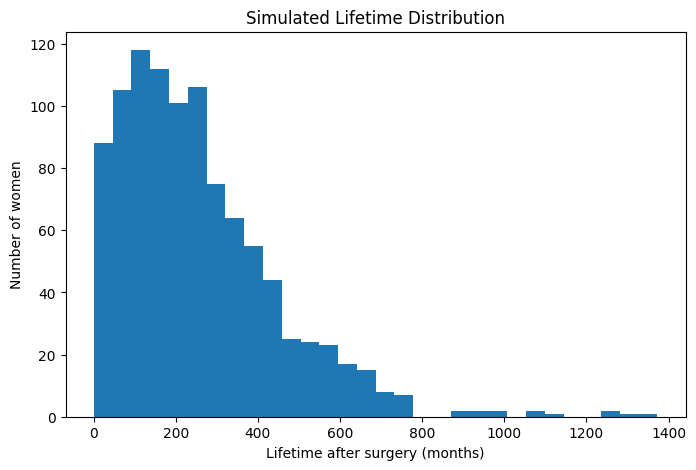

In [244]:
# Histogram
plt.figure(figsize=(8, 5))
plt.hist(lifetimes_rate, bins=30)
plt.xlabel("Lifetime after surgery (months)")
plt.ylabel("Number of women")
plt.title("Simulated Lifetime Distribution")
plt.show()

# Task 8

In [245]:
from scipy.linalg import expm

In [246]:
Qs = np.array([
    [-0.0085, 0.0050, 0.0025, 0.0000],
    [ 0.0000,-0.0140, 0.0050, 0.0040],
    [ 0.0000, 0.0000,-0.0080, 0.0030],
    [ 0.0000, 0.0000, 0.0000,-0.0090]
])

p0 = np.array([1,0,0,0])

F_T = []
max_t = np.max(life_time_rate)
times = np.linspace(0,max_t)
for t in times:
    F_T.append(1 - p0@expm(Qs*t)@np.ones(4))

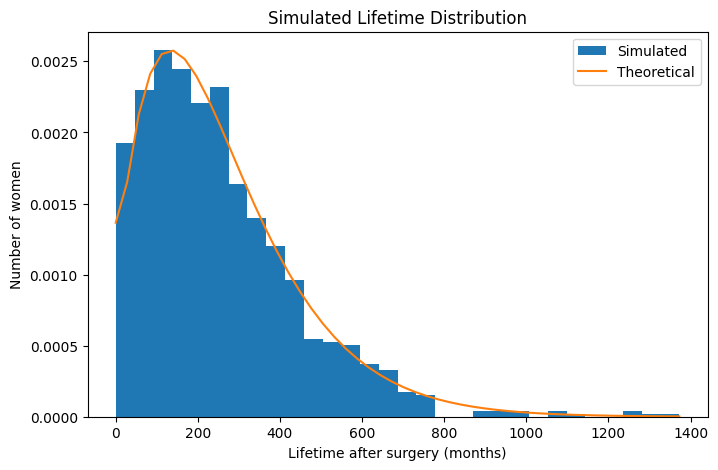

In [247]:
f_t = np.gradient(F_T,times)

# Histogram
plt.figure(figsize=(8, 5))
plt.hist(lifetimes_rate, bins=30, density=True, label = "Simulated")
plt.plot(times,f_t, label = "Theoretical")
plt.xlabel("Lifetime after surgery (months)")
plt.ylabel("Number of women")
plt.title("Simulated Lifetime Distribution")
plt.legend()
plt.show()

In [248]:
# chi square
bins = np.linspace(0, np.max(life_time_rate), 10)

obs_counts, _ = np.histogram(life_time_rate, bins=bins)

# Compute expected counts 
expected_counts = []

for i in range(len(bins) - 1):
    t1, t2 = bins[i], bins[i+1]

    F1 = 1 - p0 @ expm(Qs * t1) @ np.ones(4)
    F2 = 1 - p0 @ expm(Qs * t2) @ np.ones(4)

    expected_counts.append(len(life_time_rate) * (F2 - F1))

expected_counts = np.array(expected_counts)

mask = expected_counts >= 5

obs_counts = obs_counts[mask]
expected_counts = expected_counts[mask]

chi2_stat = np.sum((obs_counts - expected_counts)**2 / expected_counts)

df = len(obs_counts) - 1

p_value = 1 - stats.chi2.cdf(chi2_stat, df=df)

print("Chi-square:", chi2_stat)
print("p-value:", p_value)

Chi-square: 7.233608036637046
p-value: 0.20383822622164127


# Task 9

In [249]:
def diag_elements(Q):
    for i in range(np.shape(Q)[0]):
        Q[i,i] = -np.sum(Q[i])
    return Q 

In [250]:
Q9 = np.array([
    [0.0, 0.0025, 0.00125, 0.0,   0.001],
    [0.0, 0.0,    0.0,     0.002, 0.005],
    [0.0, 0.0,    0.0,     0.003, 0.005],
    [0.0, 0.0,    0.0,     0.0,   0.009],
    [0.0, 0.0,    0.0,     0.0,   0.0]
])

diag_elements(Q9)

array([[-0.00475,  0.0025 ,  0.00125,  0.     ,  0.001  ],
       [ 0.     , -0.007  ,  0.     ,  0.002  ,  0.005  ],
       [ 0.     ,  0.     , -0.008  ,  0.003  ,  0.005  ],
       [ 0.     ,  0.     ,  0.     , -0.009  ,  0.009  ],
       [ 0.     ,  0.     ,  0.     ,  0.     , -0.     ]])

In [251]:
np.random.rand(42)
life_time_9 = []
for i in range(1000):
    X = sim_lifetime_women_rate(Q9)
    life_time_9.append(X[-1][0])


In [252]:
life_time_9 = np.array(life_time_9)


In [253]:
def d_t(life_time, t):
    s =life_time<=t
    return np.sum(s)

In [254]:
max_t = np.max(life_time_9)
times = np.linspace(0,max_t)
S_t = []
for t in times: 
    S_t.append((1000-d_t(life_time_9,t))/1000)


In [255]:
# Survival no treatment
np.random.rand(42)
life_time_9_notreat = []
for i in range(1000):
    X = sim_lifetime_women_rate(Q)
    life_time_9_notreat.append(X[-1][0])

S_t_notreat = []
for t in times: 
    S_t_notreat.append((1000-d_t(life_time_9_notreat,t))/1000)

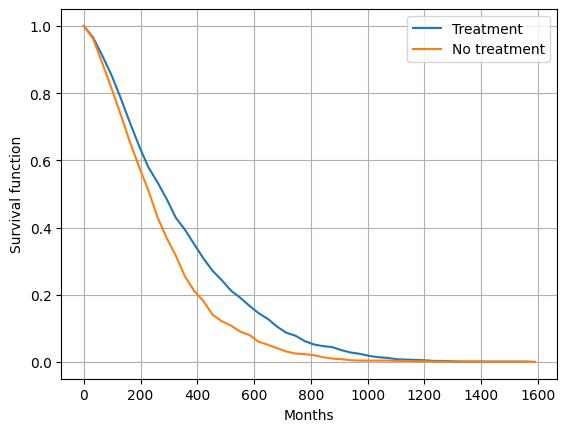

In [256]:
plt.plot(times, S_t, label= "Treatment")
plt.plot(times, S_t_notreat, label= "No treatment")
plt.xlabel("Months")
plt.ylabel("Survival function")
plt.grid()
plt.legend()
plt.show()


# Task 12

In [257]:
Simulations = []

for _ in range(1):
    Yi = []
    X = sim_lifetime_women_rate(Q)
    j = 1
    i = 1
    Yi.append(X[0][1])
    while Yi[-1]!=4: 
        if X[i][1]==4:
            Yi.append(4)
        elif X[i][0] <= j*48: 
            Yi.append(X[i][1])
        else: 
            Yi.append(X[i-1][1])
            i +=1
        j += 1

In [258]:
Simulations = []
np.random.seed(42)
for _ in range(1000):

    X = sim_lifetime_women_rate(Q)

    Yi = []
    i = 0

    for t in np.arange(0, X[-1][0] + 48, 48):

        while i + 1 < len(X) and X[i + 1][0] <= t:
            i += 1

        Yi.append(X[i][1])

        if Yi[-1] == 4:
            break

    Simulations.append(Yi)

# Task 13

In [259]:
def simulate_markov(X0, X_end, Q, t):

    state = X0
    time = 48 * t
    end_time = 48 * (t + 1)

    history = [(time, state)]

    while True:

        rate = -Q[state, state]

        if state == 4:  # No going on after death
            break

        wait = np.random.exponential(1 / rate)

        if time + wait > end_time:
            break

        time += wait

        probs = Q[state].copy()
        probs[state] = 0
        probs /= rate

        state = np.random.choice(len(Q), p=probs)

        history.append((time, state))

    # state at end_time
    if state == X_end:
        return history
    else:
        return False

In [267]:
def create_Q(maxiter, eps, Q0):
    Q = Q0
    k =0
    dif = np.inf

    while (k <= maxiter) and (dif >=eps):
        # create the full Markov chain for all women
        all_women = []
        for woman in Simulations: 
            history = [(0,0)]
            for t in range(len(woman[:-1])): 
                his_subset =simulate_markov(woman[t],woman[t+1],Q,t)
                while his_subset == False: 
                    his_subset =simulate_markov(woman[t],woman[t+1],Q,t)
                history.extend(his_subset[1:])
            all_women.append(history)

        N = np.zeros(np.shape(Q))
        S = np.zeros(np.shape(Q)[0])


        for path in all_women:
            for (t1, s1), (t2, s2) in zip(path[:-1], path[1:]):
                if s1 != s2:
                    N[s1, s2]+=1
                    duration = t2-t1
                    S[s1] +=duration
        
        for i in range(len(S)-1):
            N[i] = N[i]/S[i]

        diag_elements(N)

        dif = np.linalg.norm((Q-N),ord=np.inf)
        k+=1
        Q = N 

    return Q

In [268]:
Q0 = np.array([
    [-0.04, 0.01, 0.01, 0.01,   0.01],
    [0.0, -0.03,    0.01,     0.01, 0.01],
    [0.0, 0.0,    -0.02,     0.01, 0.01],
    [0.0, 0.0,    0.0,     -0.01,   0.01],
    [0.0, 0.0,    0.0,     0.0,   0.0]
])
create_Q(10000,10**(-3) , Q0)

array([[-0.00851929,  0.00445559,  0.00236836,  0.00056227,  0.00113307],
       [ 0.        , -0.01319186,  0.00592751,  0.0029007 ,  0.00436366],
       [ 0.        ,  0.        , -0.00824169,  0.00303641,  0.00520528],
       [ 0.        ,  0.        ,  0.        , -0.00992183,  0.00992183],
       [ 0.        ,  0.        ,  0.        ,  0.        , -0.        ]])

In [269]:
Q

array([[-0.0085,  0.005 ,  0.0025,  0.    ,  0.001 ],
       [ 0.    , -0.014 ,  0.005 ,  0.004 ,  0.005 ],
       [ 0.    ,  0.    , -0.008 ,  0.003 ,  0.005 ],
       [ 0.    ,  0.    ,  0.    , -0.009 ,  0.009 ],
       [ 0.    ,  0.    ,  0.    ,  0.    ,  0.    ]])